# 06 Error Slicing

This notebook examines errors of the selected model by customer subgroups.

Global metrics are useful, but they can hide uneven model behavior. Error slicing helps answer questions such as:

- Does the model identify churn customers equally well across customer groups?
- Are retention candidates in some segments less reliable than in others?
- Do combinations of customer characteristics reveal patterns that are not visible in one-dimensional slices?


## Slicing Scope

We use the saved predictions from the XGBoost tuning notebook and focus on the selected winning model: `XGBoost Bayesian Search`.

Single slices:

- `Contract`
- `TenureGroup`
- `InternetService`
- `PaymentMethod`
- `SeniorCitizen`
- `MonthlyChargesBand`

Selected cross-classifications:

- `Contract` x `TenureGroup`
- `Contract` x `InternetService`
- `TenureGroup` x `MonthlyChargesBand`

The single-slice diagnostics are the main view. Cross-classifications are used only as a second diagnostic layer: they help check whether combinations of customer characteristics reveal additional weak spots. Small groups can produce unstable metrics, so group sizes are shown and a minimum group-size filter is used for visualizations.


## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 160)

MIN_GROUP_SIZE = 30
SELECTED_MODEL_NAME = "XGBoost Bayesian Search"

GOOD_METRICS = {"accuracy", "precision", "recall", "f1"}
RISK_METRICS = {"false_negative_rate", "false_positive_rate"}


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "reports" / "model_results").exists():
            return path
    raise FileNotFoundError("Could not find project root with reports/model_results.")


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")


Project root: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master
Model results directory: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results


## 2. Load Selected Model Predictions

In [2]:
xgboost_predictions = pd.read_csv(MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv")

predictions = xgboost_predictions[
    xgboost_predictions["model_name"].eq(SELECTED_MODEL_NAME)
].copy()

if predictions.empty:
    available_models = sorted(xgboost_predictions["model_name"].dropna().unique())
    raise ValueError(
        f"No predictions found for {SELECTED_MODEL_NAME!r}. "
        f"Available models: {available_models}"
    )

print(predictions["model_name"].value_counts())
predictions.head()


model_name
XGBoost Bayesian Search    1409
Name: count, dtype: int64


,model_name,row_id,customerID,Contract,TenureGroup,InternetService,PaymentMethod,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,ChurnBinary,y_true,y_pred,churn_probability
4227,XGBoost Bayesian Search,0,4376-KFVRS,Two year,49+ months,Fiber optic,Credit card (automatic),0,114.05,8468.20,No,0,0,0,0.035957
4228,XGBoost Bayesian Search,1,2754-SDJRD,Month-to-month,7-12 months,Fiber optic,Credit card (automatic),1,100.15,908.55,No,0,0,1,0.725525
4229,XGBoost Bayesian Search,2,9917-KWRBE,One year,25-48 months,DSL,Credit card (automatic),0,78.35,3211.20,No,0,0,0,0.075791
4230,XGBoost Bayesian Search,3,0365-GXEZS,Month-to-month,13-24 months,Fiber optic,Electronic check,0,78.20,1468.75,No,0,0,0,0.375989
4231,XGBoost Bayesian Search,4,9385-NXKDA,Two year,49+ months,DSL,Credit card (automatic),0,82.65,5919.35,No,0,0,0,0.024084


In [3]:
required_columns = {
    "model_name",
    "row_id",
    "customerID",
    "Contract",
    "TenureGroup",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizen",
    "MonthlyCharges",
    "y_true",
    "y_pred",
    "churn_probability",
}

missing_columns = required_columns - set(predictions.columns)
if missing_columns:
    raise ValueError(f"Missing columns for error slicing: {sorted(missing_columns)}")

print("All required columns are available.")


All required columns are available.


## 3. Add Error Labels and Monthly Charge Bands

In [4]:
def classify_error(row: pd.Series) -> str:
    if row["y_true"] == 1 and row["y_pred"] == 1:
        return "true_positive"
    if row["y_true"] == 0 and row["y_pred"] == 0:
        return "true_negative"
    if row["y_true"] == 0 and row["y_pred"] == 1:
        return "false_positive"
    if row["y_true"] == 1 and row["y_pred"] == 0:
        return "false_negative"
    return "unknown"


predictions["error_type"] = predictions.apply(classify_error, axis=1)

charge_bins = [0, 35, 70, 105, np.inf]
charge_labels = ["low", "medium", "high", "very_high"]
predictions["MonthlyChargesBand"] = pd.cut(
    predictions["MonthlyCharges"],
    bins=charge_bins,
    labels=charge_labels,
    include_lowest=True,
).astype("object")

predictions[["customerID", "y_true", "y_pred", "churn_probability", "error_type", "MonthlyChargesBand"]].head()


,customerID,y_true,y_pred,churn_probability,error_type,MonthlyChargesBand
4227,4376-KFVRS,0,0,0.035957,true_negative,very_high
4228,2754-SDJRD,0,1,0.725525,false_positive,high
4229,9917-KWRBE,0,0,0.075791,true_negative,high
4230,0365-GXEZS,0,0,0.375989,true_negative,high
4231,9385-NXKDA,0,0,0.024084,true_negative,high


## 4. Global Metrics

In [5]:
def calculate_metrics(df: pd.DataFrame) -> dict:
    y_true = df["y_true"]
    y_pred = df["y_pred"]

    positives = int((y_true == 1).sum())
    negatives = int((y_true == 0).sum())
    false_negatives = int(((y_true == 1) & (y_pred == 0)).sum())
    false_positives = int(((y_true == 0) & (y_pred == 1)).sum())

    return {
        "n": len(df),
        "churn_rate": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_negative_rate": false_negatives / positives if positives else np.nan,
        "false_positive_rate": false_positives / negatives if negatives else np.nan,
        "avg_churn_probability": df["churn_probability"].mean(),
    }


global_metrics = pd.DataFrame([{ "model_name": SELECTED_MODEL_NAME, **calculate_metrics(predictions)}])
global_metrics.round(4)


,model_name,n,churn_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
0,XGBoost Bayesian Search,1409,0.2654,0.8077,0.6782,0.5241,0.5913,0.4759,0.0899,0.2667


### Interpreting Precision, Recall, and F1

For churn prediction, the three metrics answer different business questions:

- `Precision`: Of all customers the model flags as likely to churn, how many actually churn? Low precision means many retention actions may be spent on customers who would have stayed anyway.
- `Recall`: Of all customers who actually churn, how many does the model find? Low recall means the model misses many churn customers.
- `F1`: A combined score that balances precision and recall. It is useful when both unnecessary retention actions and missed churn customers matter.

In error slicing, these metrics help identify whether a subgroup mainly suffers from missed churn cases (`recall`) or unreliable churn alerts (`precision`).


## 5. Single-Slice Metrics

In [6]:
SLICE_COLUMNS = [
    "Contract",
    "TenureGroup",
    "InternetService",
    "PaymentMethod",
    "SeniorCitizen",
    "MonthlyChargesBand",
]


def calculate_slice_metrics(df: pd.DataFrame, slice_column: str) -> pd.DataFrame:
    rows = []
    for slice_value, group in df.groupby(slice_column, dropna=False):
        rows.append({
            "slice_column": slice_column,
            "slice_value": str(slice_value),
            "model_name": SELECTED_MODEL_NAME,
            **calculate_metrics(group),
        })
    return pd.DataFrame(rows)


slice_metrics = pd.concat(
    [calculate_slice_metrics(predictions, column) for column in SLICE_COLUMNS],
    ignore_index=True,
)

slice_metrics.head()


,slice_column,slice_value,model_name,n,churn_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
0,Contract,Month-to-month,XGBoost Bayesian Search,773,0.425614,0.707633,0.678201,0.595745,0.634304,0.404255,0.209459,0.429696
1,Contract,One year,XGBoost Bayesian Search,300,0.120000,0.880000,0.000000,0.000000,0.000000,1.000000,0.000000,0.104293
2,Contract,Two year,XGBoost Bayesian Search,336,0.026786,0.973214,0.000000,0.000000,0.000000,1.000000,0.000000,0.036595
3,TenureGroup,0-6 months,XGBoost Bayesian Search,311,0.556270,0.691318,0.717514,0.734104,0.725714,0.265896,0.362319,0.516379
4,TenureGroup,13-24 months,XGBoost Bayesian Search,206,0.291262,0.786408,0.700000,0.466667,0.560000,0.533333,0.082192,0.306623


In [7]:
slice_metrics.sort_values(
    ["false_negative_rate", "n"],
    ascending=[False, False],
).round(4).head(20)


,slice_column,slice_value,model_name,n,churn_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
2,Contract,Two year,XGBoost Bayesian Search,336,0.0268,0.9732,0.0000,0.0000,0.0000,1.0000,0.0000,0.0366
10,InternetService,No,XGBoost Bayesian Search,312,0.0801,0.9199,0.0000,0.0000,0.0000,1.0000,0.0000,0.0772
1,Contract,One year,XGBoost Bayesian Search,300,0.1200,0.8800,0.0000,0.0000,0.0000,1.0000,0.0000,0.1043
6,TenureGroup,49+ months,XGBoost Bayesian Search,450,0.0778,0.9244,0.6667,0.0571,0.1053,0.9429,0.0024,0.0976
18,MonthlyChargesBand,low,XGBoost Bayesian Search,349,0.1203,0.8968,0.7500,0.2143,0.3333,0.7857,0.0098,0.1127
5,TenureGroup,25-48 months,XGBoost Bayesian Search,304,0.2105,0.8125,0.6296,0.2656,0.3736,0.7344,0.0417,0.2000
20,MonthlyChargesBand,very_high,XGBoost Bayesian Search,101,0.2475,0.7921,0.7000,0.2800,0.4000,0.7200,0.0395,0.2196
12,PaymentMethod,Credit card (automatic),XGBoost Bayesian Search,309,0.1650,0.8608,0.6818,0.2941,0.4110,0.7059,0.0271,0.1686
8,InternetService,DSL,XGBoost Bayesian Search,484,0.2004,0.8306,0.6667,0.3093,0.4225,0.6907,0.0388,0.1938
11,PaymentMethod,Bank transfer (automatic),XGBoost Bayesian Search,300,0.1900,0.8567,0.8182,0.3158,0.4557,0.6842,0.0165,0.1588


## 6. Single-Slice Diagnostics

For one-dimensional slices, bar charts are easier to read than one-column heatmaps. The bars below use the same traffic-light idea as the heatmaps: higher values are better and therefore greener.


In [8]:
def metric_colormap(metric: str) -> str:
    if metric in GOOD_METRICS:
        return "RdYlGn"
    if metric in RISK_METRICS:
        return "RdYlGn_r"
    return "viridis"


def metric_label(metric: str) -> str:
    return metric.replace("_", " ").title()


def bar_color(values: pd.Series, metric: str):
    cmap = plt.get_cmap(metric_colormap(metric))
    normalized = values.clip(lower=0, upper=1).fillna(0)
    return [cmap(value) for value in normalized]


def plot_single_slice_bars(
    metrics_df: pd.DataFrame,
    slice_column: str,
    metrics: list[str],
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    plot_df = metrics_df[
        (metrics_df["slice_column"] == slice_column)
        & (metrics_df["n"] >= min_group_size)
    ].copy()

    if plot_df.empty:
        print(f"No groups with n >= {min_group_size} for {slice_column}.")
        return

    plot_df = plot_df.sort_values("recall")
    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4.8 * len(metrics), max(3, 0.55 * len(plot_df))),
        sharey=True,
        squeeze=False,
    )

    y_positions = np.arange(len(plot_df))

    for ax, metric in zip(axes[0], metrics):
        values = plot_df[metric]
        ax.barh(y_positions, values, color=bar_color(values, metric), edgecolor="white")
        ax.set_title(metric_label(metric))
        ax.set_xlim(0, 1)
        ax.set_xlabel("Score")
        ax.grid(axis="x", alpha=0.25)

        for y_pos, value, count in zip(y_positions, values, plot_df["n"]):
            label = "n/a" if pd.isna(value) else f"{value:.2f} | n={int(count)}"
            ax.text(min(value + 0.02, 0.98) if pd.notna(value) else 0.02, y_pos, label, va="center", fontsize=8)

    axes[0][0].set_yticks(y_positions)
    axes[0][0].set_yticklabels(plot_df["slice_value"])
    fig.suptitle(f"{slice_column} slices", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


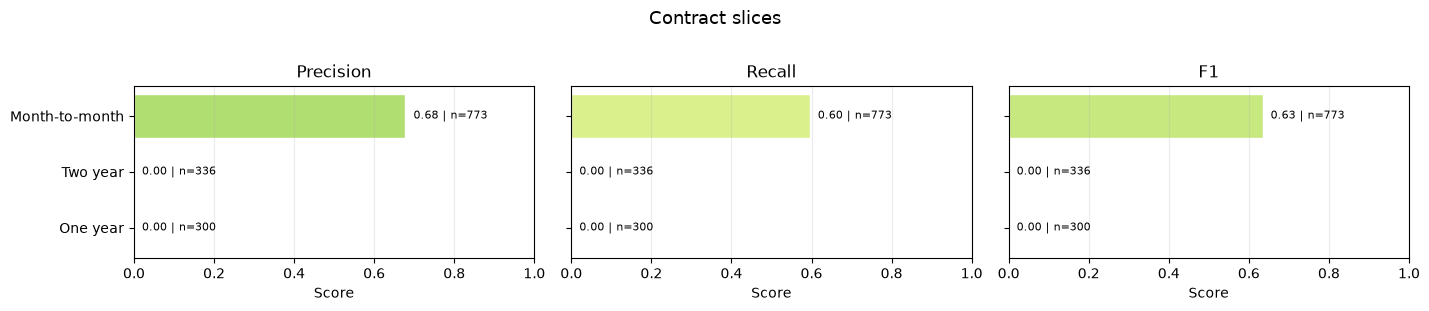

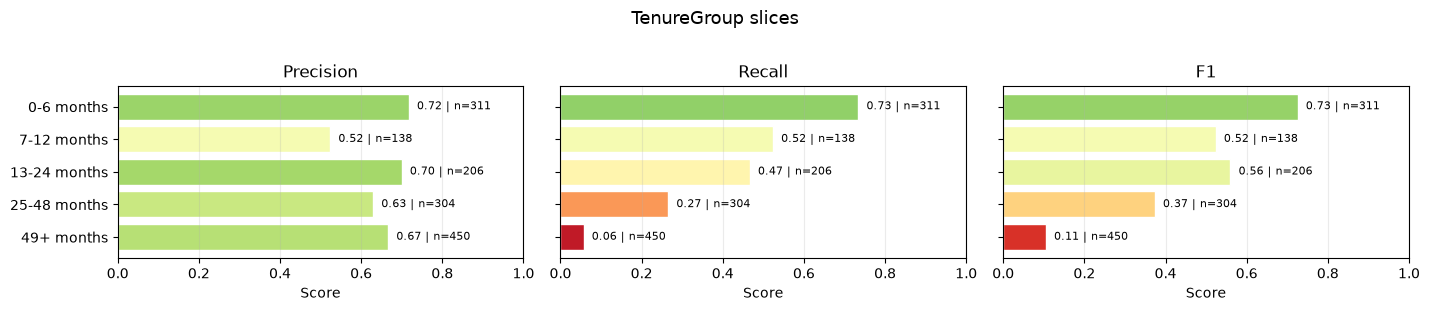

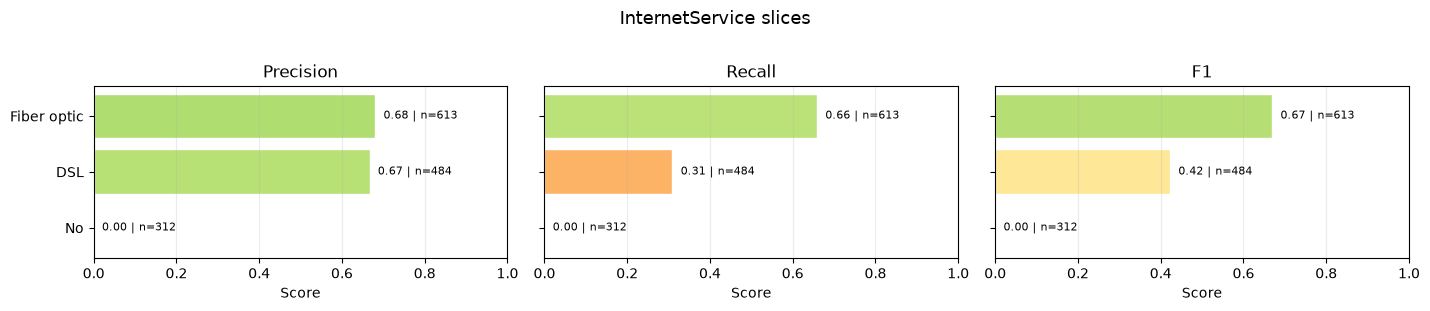

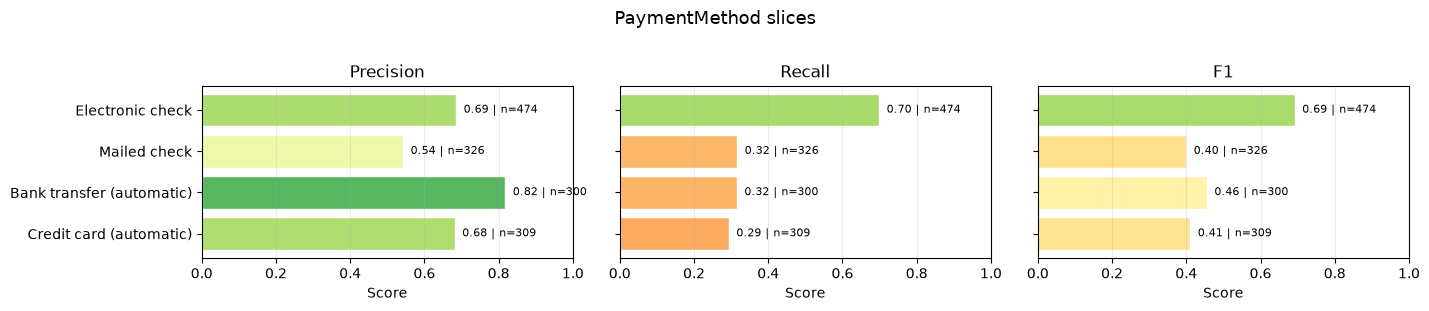

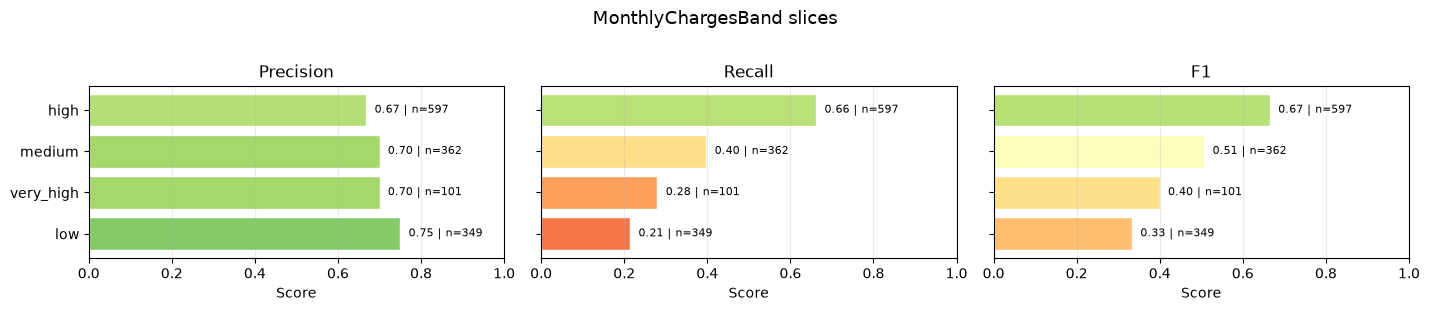

In [9]:
for column in ["Contract", "TenureGroup", "InternetService", "PaymentMethod", "MonthlyChargesBand"]:
    plot_single_slice_bars(
        slice_metrics,
        column,
        metrics=["precision", "recall", "f1"],
    )


## 7. Cross-Classification Metrics

In [10]:
CROSS_SLICE_PAIRS = [
    ("Contract", "TenureGroup"),
    ("Contract", "InternetService"),
    ("TenureGroup", "MonthlyChargesBand"),
]


def calculate_cross_slice_metrics(df: pd.DataFrame, row_column: str, column_column: str) -> pd.DataFrame:
    rows = []
    for (row_value, column_value), group in df.groupby([row_column, column_column], dropna=False):
        rows.append({
            "row_column": row_column,
            "column_column": column_column,
            "row_value": str(row_value),
            "column_value": str(column_value),
            "model_name": SELECTED_MODEL_NAME,
            **calculate_metrics(group),
        })
    return pd.DataFrame(rows)


cross_slice_metrics = pd.concat(
    [calculate_cross_slice_metrics(predictions, row_col, col_col) for row_col, col_col in CROSS_SLICE_PAIRS],
    ignore_index=True,
)

cross_slice_metrics.head()


,row_column,column_column,row_value,column_value,model_name,n,churn_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
0,Contract,TenureGroup,Month-to-month,0-6 months,XGBoost Bayesian Search,291,0.584192,0.680412,0.717514,0.747059,0.731988,0.252941,0.413223,0.543174
1,Contract,TenureGroup,Month-to-month,13-24 months,XGBoost Bayesian Search,157,0.356688,0.745223,0.700000,0.500000,0.583333,0.500000,0.118812,0.381226
2,Contract,TenureGroup,Month-to-month,25-48 months,XGBoost Bayesian Search,152,0.335526,0.710526,0.629630,0.333333,0.435897,0.666667,0.099010,0.327126
3,Contract,TenureGroup,Month-to-month,49+ months,XGBoost Bayesian Search,64,0.187500,0.828125,0.666667,0.166667,0.266667,0.833333,0.019231,0.308943
4,Contract,TenureGroup,Month-to-month,7-12 months,XGBoost Bayesian Search,109,0.366972,0.651376,0.523810,0.550000,0.536585,0.450000,0.289855,0.410487


In [11]:
cross_slice_metrics.sort_values(
    ["recall", "n"],
    ascending=[True, False],
).round(4).head(20)


,row_column,column_column,row_value,column_value,model_name,n,churn_rate,accuracy,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
13,Contract,TenureGroup,Two year,49+ months,XGBoost Bayesian Search,258,0.0271,0.9729,0.0,0.0,0.0,1.0,0.0000,0.0364
23,Contract,InternetService,Two year,No,XGBoost Bayesian Search,131,0.0000,1.0000,0.0,0.0,0.0,NaN,0.0000,0.0145
8,Contract,TenureGroup,One year,49+ months,XGBoost Bayesian Search,128,0.1250,0.8750,0.0,0.0,0.0,1.0,0.0000,0.1155
18,Contract,InternetService,One year,DSL,XGBoost Bayesian Search,118,0.0847,0.9153,0.0,0.0,0.0,1.0,0.0000,0.0805
21,Contract,InternetService,Two year,DSL,XGBoost Bayesian Search,116,0.0172,0.9828,0.0,0.0,0.0,1.0,0.0000,0.0272
37,TenureGroup,MonthlyChargesBand,49+ months,low,XGBoost Bayesian Search,106,0.0000,1.0000,0.0,0.0,0.0,NaN,0.0000,0.0191
7,Contract,TenureGroup,One year,25-48 months,XGBoost Bayesian Search,105,0.1048,0.8952,0.0,0.0,0.0,1.0,0.0000,0.0858
19,Contract,InternetService,One year,Fiber optic,XGBoost Bayesian Search,103,0.2233,0.7767,0.0,0.0,0.0,1.0,0.0000,0.1807
17,Contract,InternetService,Month-to-month,No,XGBoost Bayesian Search,102,0.2157,0.7843,0.0,0.0,0.0,1.0,0.0000,0.1863
22,Contract,InternetService,Two year,Fiber optic,XGBoost Bayesian Search,89,0.0787,0.9213,0.0,0.0,0.0,1.0,0.0000,0.0814


## 8. Selected Cross-Classification Heatmaps

The cross-classification view is intentionally limited.

The one-dimensional slices already show the main patterns. Here we only inspect a few meaningful combinations and focus on `recall`: among actual churn customers in this segment, how many does the model find?

Low recall is shown in red because it means actual churn customers are missed. High recall is shown in green. Each cell also shows the group size. Very small cells should be interpreted cautiously.

Precision and F1 are still available in the saved cross-slice table, but plotting all metrics for all combinations would make the notebook harder to read without necessarily adding insight.


In [12]:
def plot_cross_metric_heatmap(
    metrics_df: pd.DataFrame,
    row_column: str,
    column_column: str,
    metric: str,
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    plot_df = metrics_df[
        (metrics_df["row_column"] == row_column)
        & (metrics_df["column_column"] == column_column)
    ].copy()

    value_pivot = plot_df.pivot(index="row_value", columns="column_value", values=metric)
    count_pivot = plot_df.pivot(index="row_value", columns="column_value", values="n")

    value_pivot = value_pivot.where(count_pivot >= min_group_size)

    fig_width = max(7, 1.5 * len(value_pivot.columns))
    fig_height = max(3.5, 0.75 * len(value_pivot.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    matrix = value_pivot.to_numpy(dtype=float)
    image = ax.imshow(matrix, aspect="auto", cmap=metric_colormap(metric), vmin=0, vmax=1)

    ax.set_title(f"{metric_label(metric)} by {row_column} and {column_column}")
    ax.set_xlabel(column_column)
    ax.set_ylabel(row_column)
    ax.set_xticks(np.arange(len(value_pivot.columns)))
    ax.set_xticklabels(value_pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(value_pivot.index)))
    ax.set_yticklabels(value_pivot.index)

    for row_idx, row_value in enumerate(value_pivot.index):
        for col_idx, col_value in enumerate(value_pivot.columns):
            count = count_pivot.loc[row_value, col_value]
            value = value_pivot.loc[row_value, col_value]
            if pd.isna(value):
                label = f"n={int(count)}" if pd.notna(count) else "n/a"
            else:
                label = f"{value:.2f}\nn={int(count)}"
            ax.text(col_idx, row_idx, label, ha="center", va="center", fontsize=8)

    fig.colorbar(image, ax=ax, label=metric_label(metric))
    plt.tight_layout()
    plt.show()


def plot_cross_heatmap_matrix(
    metrics_df: pd.DataFrame,
    row_column: str,
    column_column: str,
    metrics: list[str],
    min_group_size: int = MIN_GROUP_SIZE,
) -> None:
    for metric in metrics:
        plot_cross_metric_heatmap(
            metrics_df,
            row_column=row_column,
            column_column=column_column,
            metric=metric,
            min_group_size=min_group_size,
        )


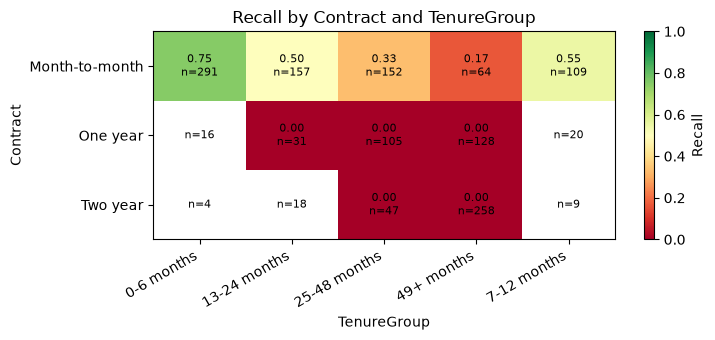

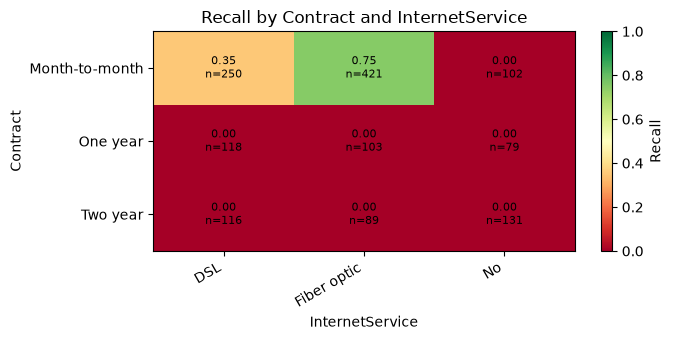

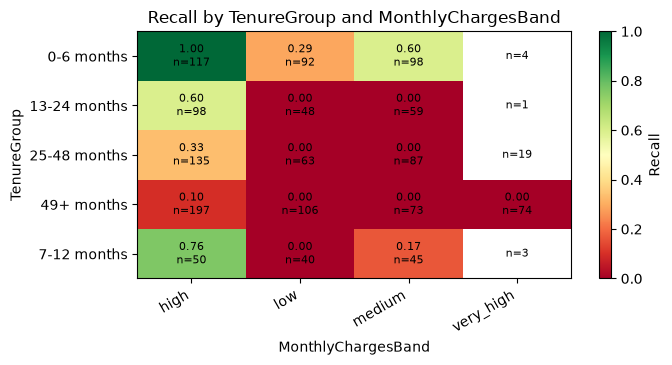

In [13]:
for row_column, column_column in CROSS_SLICE_PAIRS:
    plot_cross_metric_heatmap(
        cross_slice_metrics,
        row_column=row_column,
        column_column=column_column,
        metric="recall",
    )


## 9. Cross-Slices to Inspect First

In [14]:
inspection_candidates = cross_slice_metrics[
    cross_slice_metrics["n"] >= MIN_GROUP_SIZE
].copy()

inspection_candidates = inspection_candidates.sort_values(
    ["recall", "precision", "n"],
    ascending=[True, True, False],
)

inspection_candidates[
    [
        "row_column",
        "column_column",
        "row_value",
        "column_value",
        "n",
        "churn_rate",
        "precision",
        "recall",
        "f1",
        "false_negative_rate",
        "false_positive_rate",
        "avg_churn_probability",
    ]
].round(4).head(20)


,row_column,column_column,row_value,column_value,n,churn_rate,precision,recall,f1,false_negative_rate,false_positive_rate,avg_churn_probability
13,Contract,TenureGroup,Two year,49+ months,258,0.0271,0.0,0.0,0.0,1.0,0.0000,0.0364
23,Contract,InternetService,Two year,No,131,0.0000,0.0,0.0,0.0,NaN,0.0000,0.0145
8,Contract,TenureGroup,One year,49+ months,128,0.1250,0.0,0.0,0.0,1.0,0.0000,0.1155
18,Contract,InternetService,One year,DSL,118,0.0847,0.0,0.0,0.0,1.0,0.0000,0.0805
21,Contract,InternetService,Two year,DSL,116,0.0172,0.0,0.0,0.0,1.0,0.0000,0.0272
37,TenureGroup,MonthlyChargesBand,49+ months,low,106,0.0000,0.0,0.0,0.0,NaN,0.0000,0.0191
7,Contract,TenureGroup,One year,25-48 months,105,0.1048,0.0,0.0,0.0,1.0,0.0000,0.0858
19,Contract,InternetService,One year,Fiber optic,103,0.2233,0.0,0.0,0.0,1.0,0.0000,0.1807
17,Contract,InternetService,Month-to-month,No,102,0.2157,0.0,0.0,0.0,1.0,0.0000,0.1863
22,Contract,InternetService,Two year,Fiber optic,89,0.0787,0.0,0.0,0.0,1.0,0.0000,0.0814


## 10. Save Error Slicing Results

In [15]:
slice_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_metrics.csv"
cross_slice_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_cross_metrics.csv"
global_metrics_path = MODEL_RESULTS_DIR / "06_error_slicing_global_metrics.csv"
predictions_with_errors_path = MODEL_RESULTS_DIR / "06_predictions_with_error_types.csv"

slice_metrics.to_csv(slice_metrics_path, index=False)
cross_slice_metrics.to_csv(cross_slice_metrics_path, index=False)
global_metrics.to_csv(global_metrics_path, index=False)
predictions.to_csv(predictions_with_errors_path, index=False)

print(f"Saved single-slice metrics to: {slice_metrics_path}")
print(f"Saved cross-slice metrics to: {cross_slice_metrics_path}")
print(f"Saved global metrics to: {global_metrics_path}")
print(f"Saved predictions with error labels to: {predictions_with_errors_path}")


Saved single-slice metrics to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/06_error_slicing_metrics.csv
Saved cross-slice metrics to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/06_error_slicing_cross_metrics.csv
Saved global metrics to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/06_error_slicing_global_metrics.csv
Saved predictions with error labels to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/06_predictions_with_error_types.csv


## Error Slicing Summary

Error slicing turns global model evaluation into subgroup diagnostics.

Use the results as starting points for questions:

- In which groups is recall low, meaning actual churn customers are often missed?
- In which groups is precision low, meaning many selected retention candidates may not actually churn?
- Which combinations of customer characteristics show weak recall?
- Are small groups driving unstable metrics?

The saved tables still include precision, recall, F1, false negative rate, and false positive rate. The main cross-classification visualization focuses on recall to keep the notebook readable and aligned with the churn question: which actual churn customers are missed?

## Reflection: Why Some Slices Are Harder

A common pattern in churn projects is visible here: slices with a high churn rate are often easier for the model, while slices with rare churn are harder.

This connects back to the data exploration. If churn is frequent in a segment, the model sees more positive examples during training and can learn more stable churn patterns. If churn is rare in a segment, the model sees fewer positive examples. It may then become conservative and mostly predict `no churn`, because this is often correct in that segment. The result can be low recall: actual churn customers are missed.

This is not only a model issue. It can also be a data issue, a threshold issue, or a feature issue.

Common strategies are:

- **More or better data for weak segments**: If a segment contains only a few churn cases, the model has limited evidence. More observations, a longer history, or additional data sources can help.
- **Review the classification threshold**: A global threshold such as `0.5` may be too strict for low-churn segments. Segment-specific thresholds can be tested, but they need a clear business justification and careful monitoring.
- **Cost-sensitive training**: If missing churn customers is especially costly, false negatives can be weighted more strongly. In XGBoost, this can be done with class weights, sample weights, or parameters such as `scale_pos_weight`.
- **Resampling**: Oversampling, undersampling, or SMOTE can make the minority class more visible during training. Resampling must happen inside the training process only, not before the train-test split.
- **Feature engineering for rare churn contexts**: Weak slices may need additional explanatory signals. For example, long-term contract customers may require information about support contacts, usage changes, price changes, or contract lifecycle.
- **Segmented models**: Separate models for different customer segments can help if the segments behave very differently and contain enough data. Otherwise, they add complexity without much benefit.
- **Probability calibration**: In low-churn segments, predicted probabilities may be poorly calibrated. Calibration methods can help if probabilities are used for business decisions.

The key lesson is that weak slice performance should not be treated as a single technical problem. It should trigger a structured discussion about data coverage, business costs, thresholds, and available features.
